## Evaluation and minimization of the loss function

In [1]:
import numpy as np
import pandas
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
from ph_refine import load_ph_data, ph_loss, ph_tilde_loss_and_grad, Lambdas

### 1st step: load data from experiments and MD simulations

this is wrong because I loaded data without performing WHAM

In [3]:
ph_vals = {'A3mer' : [3.00, 3.50, 4.00], 'A5mer' : [3.50, 4.00, 4.50]}

mol_name = 'A3mer'

data = load_ph_data(path='Simulation-data', mol_name=mol_name, obs_names=['chi', 'eRMSD'],
                 ph_vals=ph_vals[mol_name], ref_ph=4.00, g_exp=None, sigma_exp=None)

In [4]:
data

          g_exp: Array([-0.17252229, -0.22463956, -0.26805093,  1.07583431,  1.02142011,
                         1.03818499], dtype=float64)
             gs: {0: Array([[-2.291882,  0.369919],
                        [-1.462641,  0.68909 ],
                        [-2.415568,  0.666532],
                        ...,
                        [-1.283432,  1.146141],
                        [-0.592147,  1.194844],
                        [-0.692991,  1.196314]], dtype=float64), 1: Array([[-2.549456,  0.14379 ],
                        [-1.78495 ,  0.457525],
                        [ 2.767067,  1.019181],
                        ...,
                        [-0.931121,  1.180245],
                        [-0.388632,  1.166304],
                        [-0.803565,  1.224548]], dtype=float64)}
  legend_matrix: Array([[0, 1, 2],
                        [3, 4, 5]], dtype=int32)
 legend_weights: {0: array([    0, 13633, 43603, 93598]), 1: array([     0,  61367, 106397, 131402])}
 log_fugacitie

### 1st step. load data (correct)
after WHAM has been performed as described in `WHAM.ipynb`

`WHAM.ipynb` performs WHAM and returns:
- `WHAM_df.txt` (weights as output of WHAM, protonation numbers and observables from concatenated trajectories from multiple constant pH MD simulations)
- `WHAM_pops_3.98.txt` (populations of the protonation states indicated in columns at a reference pH chosen as the closest one to the pKa, namely, to 50/50 populations -- notice this value of the pH is not present in the original MD simulations, but it is very close to one of them)

In [3]:
from ph_refine import Ph_data, compute_ph_weights

In [4]:
my_df = pandas.read_csv('Simulation-data/A3mer/WHAM_df.txt', index_col=0)

my_df

,weight,n_prot,chi,eRMSD
0,7.853643e-06,1.0,-1.050246,1.054092
1,1.578589e-05,1.0,-1.043169,1.175289
2,2.126278e-07,1.0,-0.292339,1.103215
3,1.271614e-07,1.0,-0.155172,1.130084
4,5.902291e-08,1.0,-0.016830,1.108039
...,...,...,...,...
112495,1.273789e-05,1.0,-0.931121,1.180245
112496,6.969360e-07,1.0,-0.388632,1.166304
112497,5.355708e-06,1.0,-0.803565,1.224548
112498,2.534988e-06,1.0,-0.592147,1.194844


In [5]:
ref_pops = np.array(pandas.read_csv('Simulation-data/A3mer/WHAM_pops_3.98.txt', index_col=0))[0]
ref_pH = 3.98

ref_pops

array([0.51023236, 0.48976764])

In [6]:
ns_prot = np.unique(my_df['n_prot']).astype(int)

ns_prot

array([0, 1])

In [7]:
my_obs = my_df[['chi', 'eRMSD']]

gs = {}

for n_prot in ns_prot:
    gs[n_prot] = np.array(my_obs[my_df['n_prot'] == n_prot])

In [8]:
pH_vals = [3.0, 3.5, 4.0]
delta_pH_vals = np.array(pH_vals) - ref_pH

log_fugacities = -np.array(delta_pH_vals)*np.log(10)

In [9]:
avs = {}
stds = {}
kish = {}
errs = {}

for pH in pH_vals:
    logf = -pH*np.log(10)
    w = compute_ph_weights(np.log(np.array(my_df['weight'])), logf, np.array(my_df['n_prot']))
    avs[logf] = np.dot(my_obs.T, w)
    stds[logf] = np.sqrt(np.dot((my_obs**2).T, w) - avs[logf]**2)
    kish[logf] = np.sum(w**2)
    errs[logf] = stds[logf]*np.sqrt(kish[logf])

In [10]:
avs_prot = {}

for j in range(2):
    avs_prot[j] = np.dot(my_obs[my_df['n_prot'] == j].T, my_df['weight'][my_df['n_prot'] == j])/np.sum(my_df['weight'][my_df['n_prot'] == j])

avs_prot

{0: array([-0.51081261,  1.06871165]), 1: array([0.54940919, 1.22269712])}

In [11]:
print('averages:\n', pandas.DataFrame(avs))
print('\nerrors on averages:\n', pandas.DataFrame(errs))
print('\nstds:\n', pandas.DataFrame(stds))

averages:
    -6.907755  -8.059048  -9.210340
0   0.445127   0.277476  -0.003744
1   1.207551   1.183202   1.142358

errors on averages:
    -6.907755  -8.059048  -9.210340
0   0.015258   0.014024   0.013469
1   0.001854   0.001833   0.001902

stds:
    -6.907755  -8.059048  -9.210340
0   1.575605   1.670041   1.782398
1   0.191443   0.218231   0.251736


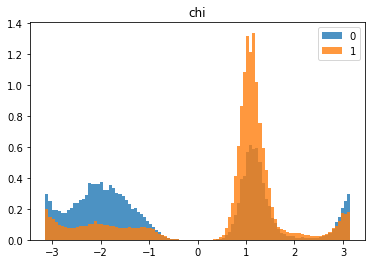

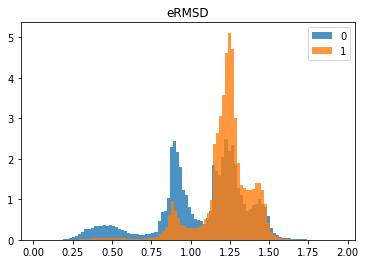

In [12]:
obs_names = ['chi', 'eRMSD']

for name in obs_names:
    plt.figure()
    plt.title(name)

    for i in range(2):
        plt.hist(my_df[name][my_df['n_prot'] == i], weights=my_df['weight'][my_df['n_prot'] == i],
                alpha=0.8, bins=100, label=i, density=True)

    plt.legend()

In [13]:
weights = {}

for n_prot in ns_prot:
    weights[n_prot] = np.array(my_df['weight'][my_df['n_prot'] == n_prot])
    weights[n_prot] /= np.sum(weights[n_prot])

weights

{0: array([4.42346099e-07, 1.18166257e-05, 1.02347386e-07, ...,
        4.79335366e-05, 2.67926326e-05, 1.36390210e-05]),
 1: array([7.85449964e-06, 1.57876092e-05, 2.12651042e-07, ...,
        6.97012053e-07, 5.35629209e-06, 2.53526442e-06])}

In [14]:
from ph_refine import Manage_indices

In [15]:
g_exp = Manage_indices.flatten(np.array(pandas.DataFrame(avs)))
sigma_exp = Manage_indices.flatten(np.array(pandas.DataFrame(errs)))

legend_matrix = Manage_indices.build_legend(np.array(pandas.DataFrame(avs)))[0]


In [16]:
data = Ph_data(g_exp, sigma_exp, legend_matrix, gs, weights, None, ref_pH, ref_pops, log_fugacities, ns_prot, obs_names, pH_vals)

### 2nd step: evaluate the loss function for the original `data`

In [19]:
pi_vec = data.pops
lambdas_vec = np.zeros(len(data.g_exp))

out = ph_loss(lambdas=lambdas_vec, pis=pi_vec, data=data)

out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

### 3rd step: minimize the loss function through `ph_tilde_loss`
(dimensionality reduction with `lambdas`)

In [22]:
log_pi_vec = np.log(pi_vec)


In [23]:
# is_fixed = False, so inner minimization of Gamma (required to compute the gradient)
lambdas = Lambdas(np.zeros(len(data.g_exp)), False)

ph_tilde_loss_and_grad(log_pi_vec, data, lambdas)


loss, grad:  -1.1329434389867456e-16 [0. 0.]


(Array(-1.13294344e-16, dtype=float64), Array([0., 0.], dtype=float64))

In [24]:
args = (data, lambdas)

mini = minimize(ph_tilde_loss_and_grad, log_pi_vec, args=args, method='BFGS', jac=True)


loss, grad:  -1.1329434389867456e-16 [0. 0.]


In [25]:
mini

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -1.1329434389867456e-16
        x: [-6.729e-01 -7.138e-01]
      nit: 0
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[1 0]
            [0 1]]
     nfev: 1
     njev: 1

In [26]:
x = mini.x

pi_new = np.exp(x)
pi_new /= np.sum(pi_new)

pi_new

array([0.51023236, 0.48976764])

In [27]:
vars(lambdas)

{'value': array([0., 0., 0., 0., 0., 0.]), 'is_fixed': False}

### 4. evaluate `ph_loss` on the optimal solution
- do the values of the loss function agree?
- is this value lower than the starting one?

In [28]:
out = ph_loss(lambdas.value, pi_new, data)

out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

In [29]:
print(mini.fun, out.loss)

-1.1329434389867456e-16 7.693513204315125e-24


yes, they agree!

In [30]:
out

         avs: Array([[-0.51081261,  1.06871165],
                     [ 0.54940919,  1.22269712]], dtype=float64)
      avs_ph: Array([[ 0.44512738,  0.27747556, -0.00374353],
                     [ 1.20755134,  1.18320177,  1.14235782]], dtype=float64)
 check_gamma: Array(7.6935132e-24, dtype=float64)
        chi2: Array(1.53870264e-23, dtype=float64)
       dkl_p: Array([-0., -0.], dtype=float64)
      dkl_pi: Array(0., dtype=float64)
       gamma: Array(0., dtype=float64)
      log_ps: [Array([-14.63117323, -11.34600306, -16.09489306, ...,  -9.94569516,
                     -10.52738361, -11.20257568], dtype=float64), Array([-11.75442399, -11.05628515, -15.36361332, ..., -14.17646313,
                     -12.1372386 , -12.88521262], dtype=float64)]
        loss: Array(7.6935132e-24, dtype=float64)
    rel_diff: Array([[9.67767524e-13, 1.86436000e-12, 2.45334519e-12],
                     [1.07795427e-12, 1.81748212e-12, 7.00346279e-13]], dtype=float64)

#### 5th step: do WHAM

(112500, 4)


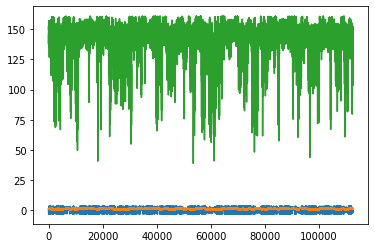

In [17]:
ph = '03.00'

totvar = np.loadtxt('Simulation-data/A3mer/TOTVAR_REWEIGHT_%s' % ph)

totvar.shape

plt.plot(totvar[:, 1:])

print(totvar.shape)

In [17]:
data.ph_vals

[3.0, 3.5, 4.0]

In [21]:
data.p0s[0].shape[0] + data.p0s[1].shape[0]

225000

In [28]:
totvars = []
colvars = []

for ph in data.ph_vals:
    print(ph)
    totvars.append(np.loadtxt('Simulation-data/A3mer/TOTVAR_REWEIGHT_0%.2f' % ph))
    colvars.append(np.loadtxt('Simulation-data/A3mer/COLVAR_REWEIGHT_0%.2f' % ph))
    print(totvars[-1].shape)


3.0
(112500, 4)
3.5
(112500, 4)
4.0
(112500, 4)


In [29]:
tot = 0

for i in range(len(data.ph_vals)):
    print(colvars[i].shape)
    tot += colvars[i].shape[0]

tot

(75001, 4)
(75001, 4)
(75001, 4)


225003

In [16]:
data.p0s[0].shape[0] + data.p0s[1].shape[0]

225000